In [1]:
import pandas as pd

In [2]:
solar_data = pd.read_csv('data/solarpower.csv')
solar_data.head()

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


In [13]:
solar_data.describe(include='all')

,date,cum_power
count,664,664.000000
unique,664,NaN
top,2017-01-01,NaN
freq,1,NaN
mean,NaN,23848.246988
std,NaN,2299.031052
min,NaN,20111.000000
25%,NaN,22071.250000
50%,NaN,24037.000000
75%,NaN,25335.500000


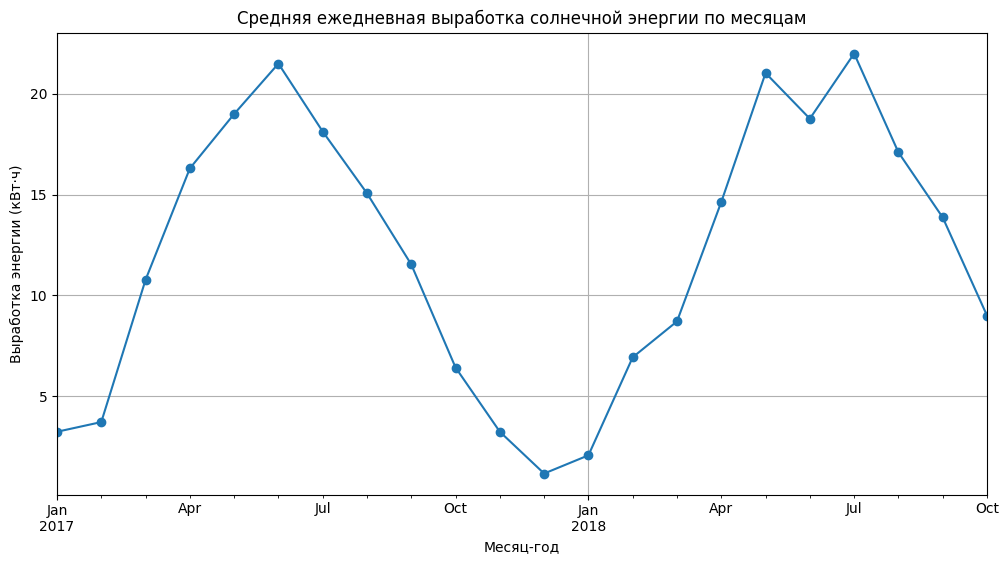

In [16]:
import matplotlib.pyplot as plt

# Преобразуем дату в datetime
solar_data['date'] = pd.to_datetime(solar_data['date'])

# Создаём столбец с ежедневной выработкой (разница между днями)
solar_data['day_power'] = solar_data['cum_power'].diff()

# Создаём столбец с периодом год-месяц
solar_data['year_month'] = solar_data['date'].dt.to_period('M')

# Считаем среднюю выработку по месяцам
monthly_avg = solar_data.groupby('year_month')['day_power'].mean()

# Строим график
plt.figure(figsize=(12, 6))
monthly_avg.plot(marker='o')

plt.title('Средняя ежедневная выработка солнечной энергии по месяцам')
plt.xlabel('Месяц-год')
plt.ylabel('Выработка энергии (кВт·ч)')
plt.grid(True)
plt.show()
